In [1]:
import pandas as pd

In [2]:
orders = pd.read_csv("/Users/rodri/Downloads/archive/olist_orders_dataset.csv")
order_items = pd.read_csv("/Users/rodri/Downloads/archive/olist_order_items_dataset.csv")
products = pd.read_csv("/Users/rodri/Downloads/archive/olist_products_dataset.csv")
customers = pd.read_csv("/Users/rodri/Downloads/archive/olist_customers_dataset.csv")
payments = pd.read_csv("/Users/rodri/Downloads/archive/olist_order_payments_dataset.csv")

In [3]:
orders.head()
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [4]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

In [5]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


In [6]:
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [7]:
orders_delivered = orders[orders['order_status'] == 'delivered']

In [8]:
orders_delivered['order_status'].value_counts()

order_status
delivered    96478
Name: count, dtype: int64

In [9]:
orders_delivered['year'] = orders_delivered['order_purchase_timestamp'].dt.year
orders_delivered['month'] = orders_delivered['order_purchase_timestamp'].dt.month
orders_delivered['year_month'] = orders_delivered['order_purchase_timestamp'].dt.to_period('M')

In [10]:
sorted(orders_delivered['year_month'].unique())

[Period('2016-09', 'M'),
 Period('2016-10', 'M'),
 Period('2016-12', 'M'),
 Period('2017-01', 'M'),
 Period('2017-02', 'M'),
 Period('2017-03', 'M'),
 Period('2017-04', 'M'),
 Period('2017-05', 'M'),
 Period('2017-06', 'M'),
 Period('2017-07', 'M'),
 Period('2017-08', 'M'),
 Period('2017-09', 'M'),
 Period('2017-10', 'M'),
 Period('2017-11', 'M'),
 Period('2017-12', 'M'),
 Period('2018-01', 'M'),
 Period('2018-02', 'M'),
 Period('2018-03', 'M'),
 Period('2018-04', 'M'),
 Period('2018-05', 'M'),
 Period('2018-06', 'M'),
 Period('2018-07', 'M'),
 Period('2018-08', 'M')]

In [11]:
orders_delivered['year_month'].dtype

period[M]

In [12]:
orders_delivered['year_month'].nunique()

23

In [13]:
total_ventas = payments['payment_value'].sum()
total_ventas

np.float64(16008872.120000001)

In [14]:
df = pd.merge(orders_delivered, payments, on="order_id")

In [15]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,year,month,year_month,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,2017-10,1,credit_card,1,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,2017-10,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,2017-10,2,voucher,1,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,2018-07,1,boleto,1,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,2018-08,1,credit_card,3,179.12


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100756 entries, 0 to 100755
Data columns (total 15 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       100756 non-null  str           
 1   customer_id                    100756 non-null  str           
 2   order_status                   100756 non-null  str           
 3   order_purchase_timestamp       100756 non-null  datetime64[us]
 4   order_approved_at              100742 non-null  datetime64[us]
 5   order_delivered_carrier_date   100754 non-null  datetime64[us]
 6   order_delivered_customer_date  100748 non-null  datetime64[us]
 7   order_estimated_delivery_date  100756 non-null  datetime64[us]
 8   year                           100756 non-null  int32         
 9   month                          100756 non-null  int32         
 10  year_month                     100756 non-null  period[M]     
 11  payment_seq

In [17]:
#VENTAS REALES

ganancia_real = df['payment_value'].sum()
ganancia_real

np.float64(15422461.77)

In [18]:
#VENTAS POR MES

ventas_por_mes = df.groupby('year_month')['payment_value'].sum()
ventas_por_mes = ventas_por_mes.sort_index()
ventas_por_mes.head()

year_month
2016-10     46566.71
2016-12        19.62
2017-01    127545.67
2017-02    271298.65
2017-03    414369.39
Freq: M, Name: payment_value, dtype: float64

In [19]:
ventas_por_mes.index = ventas_por_mes.index.to_timestamp()

<function matplotlib.pyplot.show(close=None, block=None)>

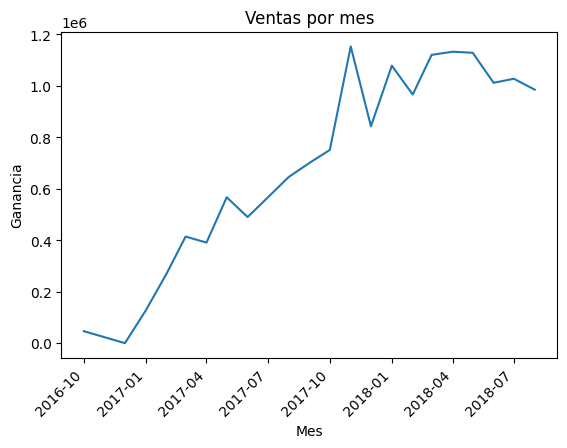

In [20]:
import matplotlib.pyplot as plt

ventas_por_mes.plot()
plt.title("Ventas por mes")
plt.xlabel("Mes")
plt.ylabel("Ganancia")
plt.xticks(rotation=45)
plt.show

In [21]:
ventas_por_mes.idxmax()

Timestamp('2017-11-01 00:00:00')

In [22]:
ventas_por_mes.max()

np.float64(1153528.05)

In [23]:
crecimiento = ventas_por_mes.pct_change()

In [24]:
crecimiento.head(10)

year_month
2016-10-01            NaN
2016-12-01      -0.999579
2017-01-01    6499.798675
2017-02-01       1.127071
2017-03-01       0.527355
2017-04-01      -0.056513
2017-05-01       0.450476
2017-06-01      -0.135506
2017-07-01       0.155394
2017-08-01       0.140530
Name: payment_value, dtype: float64

In [25]:
crecimiento_filtrado = crecimiento[(crecimiento < 5) & (crecimiento > -1)]

<function matplotlib.pyplot.show(close=None, block=None)>

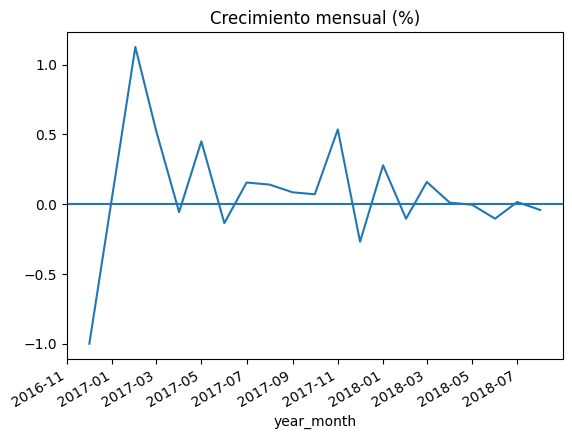

In [26]:
crecimiento_filtrado.plot()
plt.axhline(0)
plt.title("Crecimiento mensual (%)")
plt.show

In [27]:
df_items = pd.merge(order_items, products, on="product_id")

In [28]:
df_final = pd.merge(df, df_items, on='order_id')

In [29]:
df_final.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,year,month,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,...,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,...,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0


In [30]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 115035 entries, 0 to 115034
Data columns (total 29 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       115035 non-null  str           
 1   customer_id                    115035 non-null  str           
 2   order_status                   115035 non-null  str           
 3   order_purchase_timestamp       115035 non-null  datetime64[us]
 4   order_approved_at              115020 non-null  datetime64[us]
 5   order_delivered_carrier_date   115033 non-null  datetime64[us]
 6   order_delivered_customer_date  115027 non-null  datetime64[us]
 7   order_estimated_delivery_date  115035 non-null  datetime64[us]
 8   year                           115035 non-null  int32         
 9   month                          115035 non-null  int32         
 10  year_month                     115035 non-null  period[M]     
 11  payment_seq

In [31]:
ventas_categoria = df_final.groupby('product_category_name')['price'].sum()
ventas_categoria = ventas_categoria.sort_values(ascending=False)

ventas_categoria.head(10)

product_category_name
beleza_saude              1271333.29
relogios_presentes        1213440.80
cama_mesa_banho           1077968.13
esporte_lazer              990644.22
informatica_acessorios     918948.86
moveis_decoracao           746183.40
utilidades_domesticas      648187.74
cool_stuff                 634403.75
automotivo                 602999.05
ferramentas_jardim         492390.08
Name: price, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

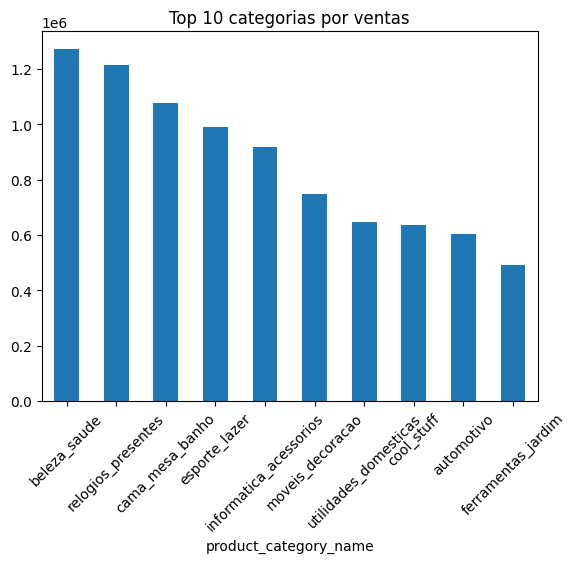

In [32]:
ventas_categoria.head(10).plot(kind='bar')
plt.title("Top 10 categorias por ventas")
plt.xticks(rotation=45)
plt.show

In [33]:
clientes_top = df.groupby('customer_id')['payment_value'].sum()
clientes_top = clientes_top.sort_values(ascending=False)

clientes_top.head(10)

customer_id
1617b1357756262bfa56ab541c47bc16    13664.08
ec5b2ba62e574342386871631fafd3fc     7274.88
c6e2731c5b391845f6800c97401a43a9     6929.31
f48d464a0baaea338cb25f816991ab1f     6922.21
3fd6777bbce08a352fddd04e4a7cc8f6     6726.66
05455dfa7cd02f13d132aa7a6a9729c6     6081.54
df55c14d1476a9a3467f131269c2477f     4950.34
24bbf5fd2f2e1b359ee7de94defc4a15     4764.34
3d979689f636322c62418b6346b1c6d2     4681.78
1afc82cd60e303ef09b4ef9837c9505c     4513.32
Name: payment_value, dtype: float64

In [34]:
# TICKET PROMEDIO

In [35]:
pedido_total = df.groupby('order_id')['payment_value'].sum()

In [36]:
ticket_promedio = pedido_total.mean()
ticket_promedio

np.float64(159.8563571628471)

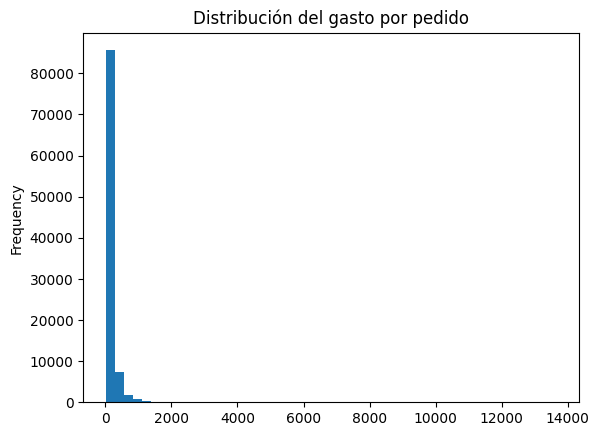

In [37]:
# DISTRIBUCION DEL GASTO

pedido_total.plot(kind='hist', bins=50)
plt.title("Distribución del gasto por pedido")
plt.show()

In [38]:
pedidos_por_mes = df.groupby('year_month')['order_id'].nunique()
pedidos_por_mes = pedidos_por_mes.sort_index()

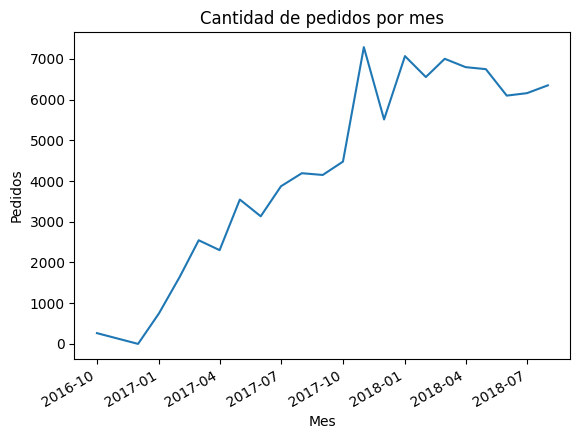

In [39]:
pedidos_por_mes.index = pedidos_por_mes.index.to_timestamp()

pedidos_por_mes.plot()
plt.title("Cantidad de pedidos por mes")
plt.xlabel("Mes")
plt.ylabel("Pedidos")
plt.show()

In [40]:
# CLIENTES RECURRENTES

In [41]:
df = pd.merge(df, customers, on='customer_id')

In [42]:
pedidos_cliente = df.groupby('customer_unique_id')['order_id'].nunique()

In [43]:
clientes_recurrentes = pedidos_cliente.sort_values(ascending=False)

clientes_recurrentes.head(10)

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    15
3e43e6105506432c953e165fb2acf44c     9
ca77025e7201e3b30c44b472ff346268     7
1b6c7548a2a1f9037c1fd3ddfed95f33     7
6469f99c1f9dfae7733b25662e7f1782     7
47c1a3033b8b77b3ab6e109eb4d5fdf3     6
12f5d6e1cbf93dafd9dcc19095df0b3d     6
f0e310a6839dce9de1638e0fe5ab282a     6
dc813062e0fc23409cd255f7f53c7074     6
63cfc61cee11cbe306bff5857d00bfe4     6
Name: order_id, dtype: int64

In [44]:
clientes_recurrentes_count = (pedidos_cliente > 1).sum()
clientes_totales = pedidos_cliente.count()

porcentaje_recurrentes = (clientes_recurrentes_count / clientes_totales) * 100

clientes_recurrentes_count, clientes_totales, porcentaje_recurrentes

(np.int64(2801), np.int64(93357), np.float64(3.0003106355174225))

## GANANCIA TOTAL DEL NEGOCIO

In [45]:
ganancia_real = df['payment_value'].sum()
print("Ganancia total:", round(ganancia_real, 2))

Ganancia total: 15422461.77


## EVOLUCION DE VENTAS EN EL TIEMPO

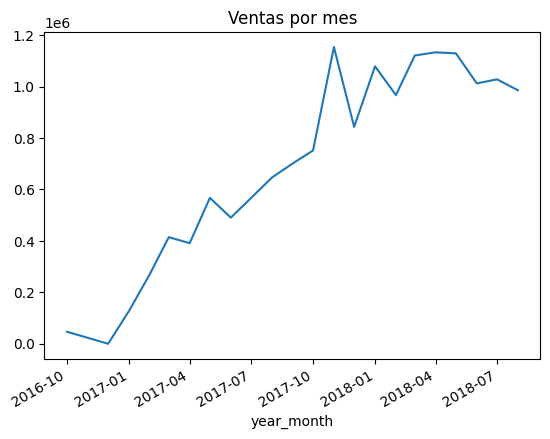

In [46]:
ventas_por_mes.plot()
plt.title("Ventas por mes")
plt.show()

In [47]:
## LAS VENTAS MUESTRAN UNA TENDENCIA CRECIENTE CON VARIACIONES MENSUALES

## CRECIMIENTO DEL NEGOCIO

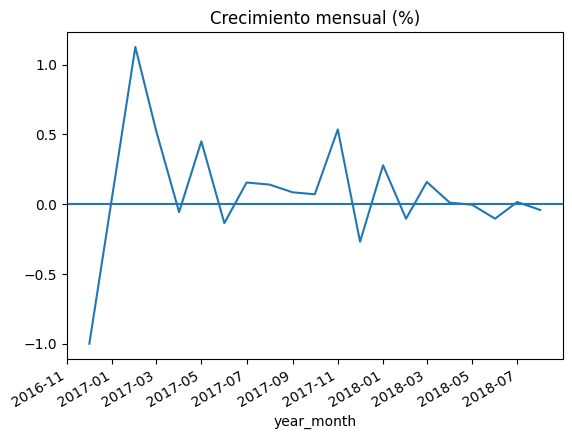

In [48]:
crecimiento_filtrado.plot()
plt.axhline(0)
plt.title("Crecimiento mensual (%)")
plt.show()

## CATEGORIAS CON MAYOR GANANCIA

In [49]:
print(ventas_categoria.head(10))

product_category_name
beleza_saude              1271333.29
relogios_presentes        1213440.80
cama_mesa_banho           1077968.13
esporte_lazer              990644.22
informatica_acessorios     918948.86
moveis_decoracao           746183.40
utilidades_domesticas      648187.74
cool_stuff                 634403.75
automotivo                 602999.05
ferramentas_jardim         492390.08
Name: price, dtype: float64


## CLIENTES QUE MAS GASTAN

In [50]:
print(clientes_top.head(10))

customer_id
1617b1357756262bfa56ab541c47bc16    13664.08
ec5b2ba62e574342386871631fafd3fc     7274.88
c6e2731c5b391845f6800c97401a43a9     6929.31
f48d464a0baaea338cb25f816991ab1f     6922.21
3fd6777bbce08a352fddd04e4a7cc8f6     6726.66
05455dfa7cd02f13d132aa7a6a9729c6     6081.54
df55c14d1476a9a3467f131269c2477f     4950.34
24bbf5fd2f2e1b359ee7de94defc4a15     4764.34
3d979689f636322c62418b6346b1c6d2     4681.78
1afc82cd60e303ef09b4ef9837c9505c     4513.32
Name: payment_value, dtype: float64


## TICKET PROMEDIO POR PEDIDO

In [51]:
print("Ticket promedio:", round(ticket_promedio, 2))

Ticket promedio: 159.86


## CANTIDAD DE PEDIDOS POR MES

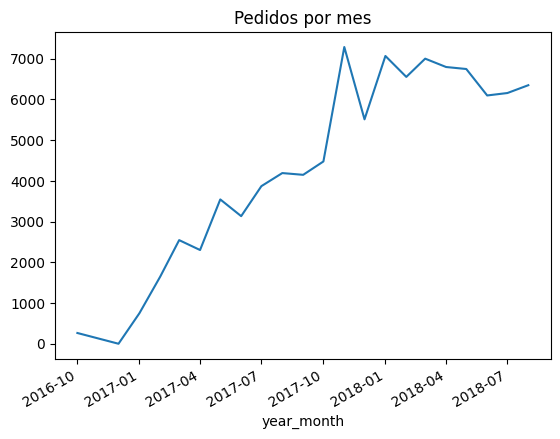

In [52]:
pedidos_por_mes.plot()
plt.title("Pedidos por mes")
plt.show()

## CLIENTES RECURRENTES

In [53]:
print("Clientes recurrentes:", clientes_recurrentes_count)
print("Clientes totales:", clientes_totales)
print("Porcentaje:", round(porcentaje_recurrentes, 2), "%")

Clientes recurrentes: 2801
Clientes totales: 93357
Porcentaje: 3.0 %


## CONCLUSION FINAL

- El negocio muestra crecimiento sostenido en ventas y pedidos
- La categoria beleza_saude lidera en ganancias
- El ticket promedio es de aproximadamente 160
- Solo el 3% de los clientes son recurrentes
- Existe una fuerte dependencia de atraer nuevos clientes

Se sugiere mejorar en estrategias de fidelización de clientes.